# Assignment III: Regularization and Optimization
**Name:** Sumira Makaju

**ID:** 032317-22

**Date:** April 19, 2026

**Dataset used:** portoseguro safe driver prediction

## Objectives

1. To understand the impact of regularization techniques (Dropout, L1/L2)
2. To compare performance of optimizers (SGD vs Adam)
3. To analyze overfitting vs generalization
4. To evaluate model performance using training and validation loss
5. To study effect of Batch Normalization

## Theoretical Background

**Overfitting and Generalization**

When a model learns the training data too well, including noise and irrelevant patterns, resulting in poor performance on unseen data, the state is called overfitting. 

Generalization refers to the model's ability to perform well on new, unseen data. The goal of training is to minimize overfitting while maximizing generalization.

**Regularization**

Regularization is a technique used to prevent overfitting by controlling how complex a model becomes. The types of regularization are as follows:

1. **L2 Regularization**
   
   L2 regularization penalizes large weights by adding the squared magnitude of weights to the loss function:

    $$
    Loss = L(y, \hat{y}) + \lambda \sum w^2
    $$

    This encourages smaller weight values and leads to smoother models.

2. **L1 Regularization**

    L1 regularization adds the absolute value of weights to the loss. It removes uselesss features.

    $$
    Loss = L(y, \hat{y}) + \lambda \sum |w|
    $$

    It promotes sparsity (many weights become zero) and also acts as a form of feature selection.


4. **Dropout**

    Dropout is a regularization technique where a fraction of neurons is randomly deactivated during training.
    This is used as prevention measure for neurons from coadapting. It improves robustness and generalization.


**Batch Normalization**

Batch Normalization normalizes the inputs of each layer:

$$
\hat{x} = \frac{x - \mu}{\sigma}
$$

It stabilizes training, allows higher learning rates, and has a mild regularizing effect.

**Stochastic Gradient Descent (SGD)**

SGD updates weights using gradients computed from mini-batches. It updates weights using the raw gradient and is usually simple but slow and sensitive to learning rate.

$$
w = w - \eta \nabla L
$$

**Adam (Adaptive Moment Estimation)**

Adam combines momentum and adaptive learning rates. It uses first moment (mean) and second moment (variance) of gradients. It has faster convergence than SGD and works well for complex and noisy datasets.

**Bias-Variance Tradeoff**

1. **High Bias**: Model is too simple means underfitting
2. **High Variance**: Model is too complex means overfitting

Regularization helps reduce variance while maintaining acceptable bias.

**Loss Function**

For binary classification, Binary Cross Entropy (BCE) loss is used. It measures difference between predicted probabilities and true labels

$$
Loss = -[y \log(\hat{y}) + (1 - y)\log(1 - \hat{y})]
$$


## Dataset Description

**Source:**  ( https://www.kaggle.com/datasets/aharless/porto-seguro-public-kernel-results)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/sumiramakaju/safedriver-prediction/safedriverprediction.csv')
print(f"Shape: {df.shape}")
print(f"Features: {df.shape[1]-1} Samples: {df.shape[0]:,}")
print("\nFeature types:")
print(df.dtypes.value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (892816, 58)
Features: 57 Samples: 892,816

Feature types:
int64      48
float64    10
Name: count, dtype: int64

First 3 rows:


,id,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,0,1,8,1,0,0,1,0,0,...,1,1,1,12,0,1,1,0,0,1
1,1,4,2,5,1,0,0,0,0,1,...,2,0,3,10,0,0,1,1,0,1
2,2,5,1,3,0,0,0,0,0,1,...,4,0,2,4,0,0,0,0,0,0


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


#seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
df = pd.read_csv('/kaggle/input/datasets/sumiramakaju/safedriver-prediction/safedriverprediction.csv')
median_val = df['ps_ind_15'].median()
y = (df['ps_ind_15'] > median_val).astype(int).values
X = df.drop(columns=['ps_ind_15']).values

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#only 20,000 samples for faster training
X, _, y, _ = train_test_split(
    X, y,
    train_size=20000,
    stratify=y,            #Keep class distribution balanced
    random_state=SEED
)

#split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

#normalizing features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_val   = scaler.transform(X_val)       

#numpy arrays into PyTorch tensors
def to_tensors(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),  # Features
        torch.tensor(y, dtype=torch.float32)   # Labels
    )

#dataset objects
train_ds = to_tensors(X_train, y_train)
val_ds   = to_tensors(X_val,   y_val)

#DataLoaders (handles batching)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)

#number of input features
INPUT_DIM = X_train.shape[1]

print(f"Train size: {len(train_ds):,} Val size: {len(val_ds):,} Features: {INPUT_DIM}")

Train size: 16,000 Val size: 4,000 Features: 57


In [4]:
#Model definitions

class BaseNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


class DropoutNet(nn.Module):
  #Dropout(0.4) after each hidden layer
    def __init__(self, input_dim, p=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


class BatchNormNet(nn.Module):
   #Batch Normalization
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

In [5]:
def train_model(model, optimizer, epochs=30, l1_lambda=0.0, l2_lambda=0.0):
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        #training
        model.train()
        t_loss, t_correct = 0, 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            if l1_lambda > 0:
                l1 = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * len(y_b)
            t_correct += ((logits > 0) == y_b.bool()).sum().item()

        #validation
        model.eval()
        v_loss, v_correct = 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                logits    = model(X_b)
                v_loss   += criterion(logits, y_b).item() * len(y_b)
                v_correct += ((logits > 0) == y_b.bool()).sum().item()

        train_loss = t_loss    / len(train_ds)
        val_loss   = v_loss    / len(val_ds)
        train_acc  = t_correct / len(train_ds)
        val_acc    = v_correct / len(val_ds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:>3}/{epochs} "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}% "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%")

    return history


def plot_history(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for h, label in zip(histories, labels):
        axes[0].plot(h['train_loss'], linestyle='--', label=f'{label} Train')
        axes[0].plot(h['val_loss'],                   label=f'{label} Val')
        axes[1].plot(h['train_acc'], linestyle='--', label=f'{label} Train')
        axes[1].plot(h['val_acc'],                    label=f'{label} Val')
    for ax, ylabel in zip(axes, ['Loss (BCE)', 'Accuracy']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    axes[0].set_title(f'{title} Loss')
    axes[1].set_title(f'{title} Accuracy')
    plt.tight_layout()
    plt.show()

## Experiment 1: With vs Without Regularization

We train three models with **Adam** optimizer:
1. **No Regularization** (baseline: expect overfitting)
2. **Dropout** (p = 0.4)
3. **L2 Weight Decay** (1e-3)

no regularization

Epoch   1/30 Train Loss: 0.6442  Train Acc: 60.79% Val Loss: 0.6224  Val Acc: 63.55%
Epoch   2/30 Train Loss: 0.6080  Train Acc: 65.14% Val Loss: 0.6209  Val Acc: 63.82%
Epoch   3/30 Train Loss: 0.5946  Train Acc: 66.44% Val Loss: 0.6180  Val Acc: 64.35%
Epoch   4/30 Train Loss: 0.5823  Train Acc: 67.97% Val Loss: 0.6197  Val Acc: 64.33%
Epoch   5/30 Train Loss: 0.5722  Train Acc: 68.67% Val Loss: 0.6260  Val Acc: 63.90%
Epoch   6/30 Train Loss: 0.5588  Train Acc: 69.91% Val Loss: 0.6434  Val Acc: 63.58%
Epoch   7/30 Train Loss: 0.5399  Train Acc: 71.39% Val Loss: 0.6431  Val Acc: 64.00%
Epoch   8/30 Train Loss: 0.5209  Train Acc: 72.86% Val Loss: 0.6554  Val Acc: 63.62%
Epoch   9/30 Train Loss: 0.5003  Train Acc: 74.48% Val Loss: 0.6731  Val Acc: 62.52%
Epoch  10/30 Train Loss: 0.4714  Train Acc: 76.92% Val Loss: 0.7112  Val Acc: 61.72%
Epoch  11/30 Train Loss: 0.4488  Train Acc: 78.90% Val Loss: 0.7275  Val Acc: 62.70%
Epoch  12/30 Train Loss: 0.4079  Train Acc: 81

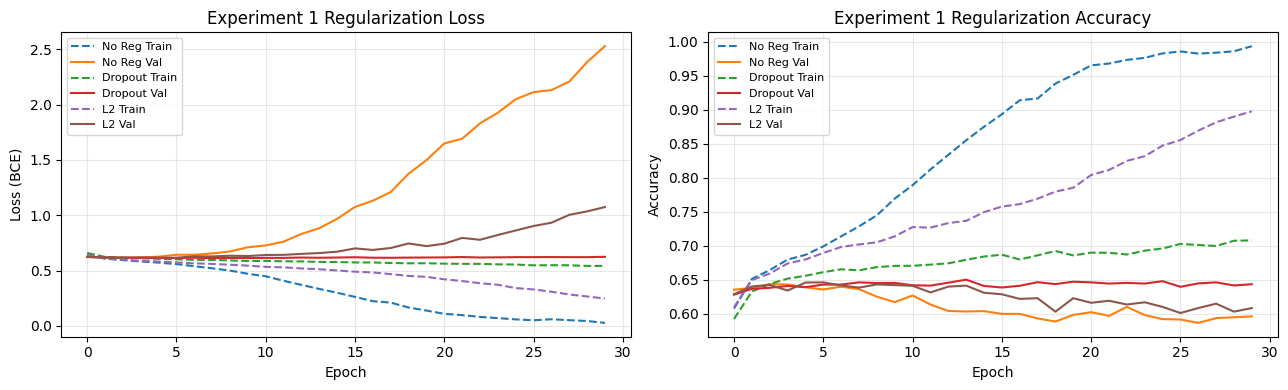

In [6]:
EPOCHS = 30
LR     = 1e-3

#Baseline (no regularization)
print("no regularization\n")
model_base = BaseNet(INPUT_DIM)
opt_base   = optim.Adam(model_base.parameters(), lr=LR)
h_base     = train_model(model_base, opt_base, epochs=EPOCHS)

#Dropout
print("\ndropout\n")
model_drop = DropoutNet(INPUT_DIM, p=0.4)
opt_drop   = optim.Adam(model_drop.parameters(), lr=LR)
h_drop     = train_model(model_drop, opt_drop, epochs=EPOCHS)

#L2 regularization
print("\nL2 regularization\n")
model_l2 = BaseNet(INPUT_DIM)
opt_l2   = optim.Adam(model_l2.parameters(), lr=LR, weight_decay=1e-3)
h_l2     = train_model(model_l2, opt_l2, epochs=EPOCHS)

plot_history(
    [h_base, h_drop, h_l2],
    ['No Reg', 'Dropout', 'L2'],
    'Experiment 1 Regularization'
)


Epoch   1/30 Train Loss: 0.6920  Train Acc: 51.52% Val Loss: 0.6898  Val Acc: 51.32%
Epoch   2/30 Train Loss: 0.6890  Train Acc: 53.31% Val Loss: 0.6850  Val Acc: 57.53%
Epoch   3/30 Train Loss: 0.6830  Train Acc: 54.95% Val Loss: 0.6737  Val Acc: 60.10%
Epoch   4/30 Train Loss: 0.6677  Train Acc: 58.77% Val Loss: 0.6519  Val Acc: 60.75%
Epoch   5/30 Train Loss: 0.6521  Train Acc: 59.67% Val Loss: 0.6369  Val Acc: 61.45%
Epoch   6/30 Train Loss: 0.6429  Train Acc: 61.00% Val Loss: 0.6304  Val Acc: 62.02%
Epoch   7/30 Train Loss: 0.6347  Train Acc: 61.95% Val Loss: 0.6273  Val Acc: 62.28%
Epoch   8/30 Train Loss: 0.6348  Train Acc: 62.01% Val Loss: 0.6268  Val Acc: 62.38%
Epoch   9/30 Train Loss: 0.6304  Train Acc: 62.60% Val Loss: 0.6243  Val Acc: 62.98%
Epoch  10/30 Train Loss: 0.6268  Train Acc: 62.95% Val Loss: 0.6233  Val Acc: 63.18%
Epoch  11/30 Train Loss: 0.6263  Train Acc: 62.92% Val Loss: 0.6227  Val Acc: 63.15%
Epoch  12/30 Train Loss: 0.6246  Train Acc: 63.09% Val Loss: 0.62

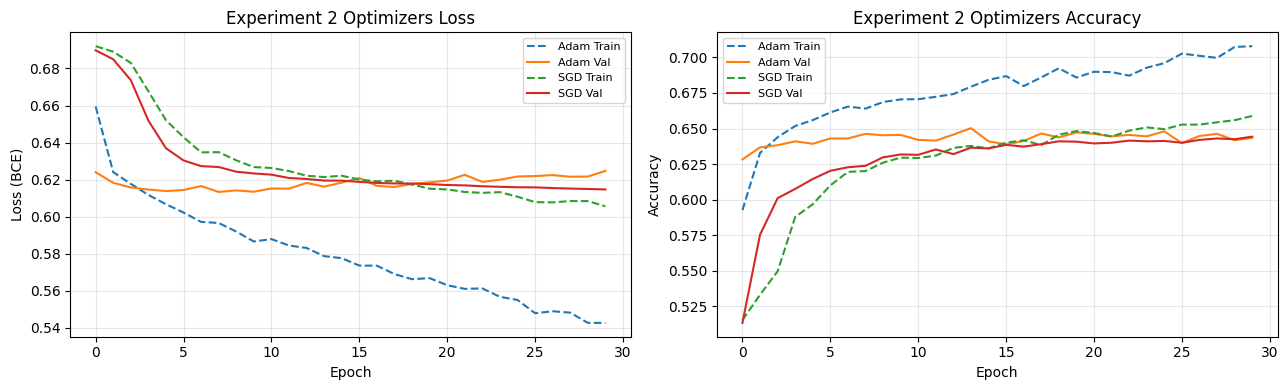

In [7]:
#Adam and Dropout (reuse from above)
# h_drop is already computed above

#SGD and Dropout
model_sgd = DropoutNet(INPUT_DIM, p=0.4)
opt_sgd   = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
h_sgd     = train_model(model_sgd, opt_sgd, epochs=EPOCHS)
print("SGD done.")

plot_history(
    [h_drop, h_sgd],
    ['Adam', 'SGD'],
    'Experiment 2 Optimizers'
)


## Experiment 3: Overfitting Demonstration

Classic overfitting signature: training loss keeps falling while validation loss rises.

Epoch   1/40 Train Loss: 0.6318  Train Acc: 62.25% Val Loss: 0.6183  Val Acc: 63.30%
Epoch   2/40 Train Loss: 0.6047  Train Acc: 65.52% Val Loss: 0.6170  Val Acc: 64.08%
Epoch   3/40 Train Loss: 0.5891  Train Acc: 66.47% Val Loss: 0.6219  Val Acc: 64.18%
Epoch   4/40 Train Loss: 0.5737  Train Acc: 68.56% Val Loss: 0.6296  Val Acc: 63.40%
Epoch   5/40 Train Loss: 0.5583  Train Acc: 69.60% Val Loss: 0.6239  Val Acc: 64.15%
Epoch   6/40 Train Loss: 0.5385  Train Acc: 71.09% Val Loss: 0.6506  Val Acc: 63.28%
Epoch   7/40 Train Loss: 0.5132  Train Acc: 72.96% Val Loss: 0.6615  Val Acc: 63.75%
Epoch   8/40 Train Loss: 0.4804  Train Acc: 75.26% Val Loss: 0.7076  Val Acc: 62.18%
Epoch   9/40 Train Loss: 0.4421  Train Acc: 78.20% Val Loss: 0.7502  Val Acc: 62.58%
Epoch  10/40 Train Loss: 0.3975  Train Acc: 81.12% Val Loss: 0.8082  Val Acc: 60.10%
Epoch  11/40 Train Loss: 0.3398  Train Acc: 84.29% Val Loss: 0.8912  Val Acc: 61.18%
Epoch  12/40 Train Loss: 0.2770  Train Acc: 87.76% Val Loss: 1.07

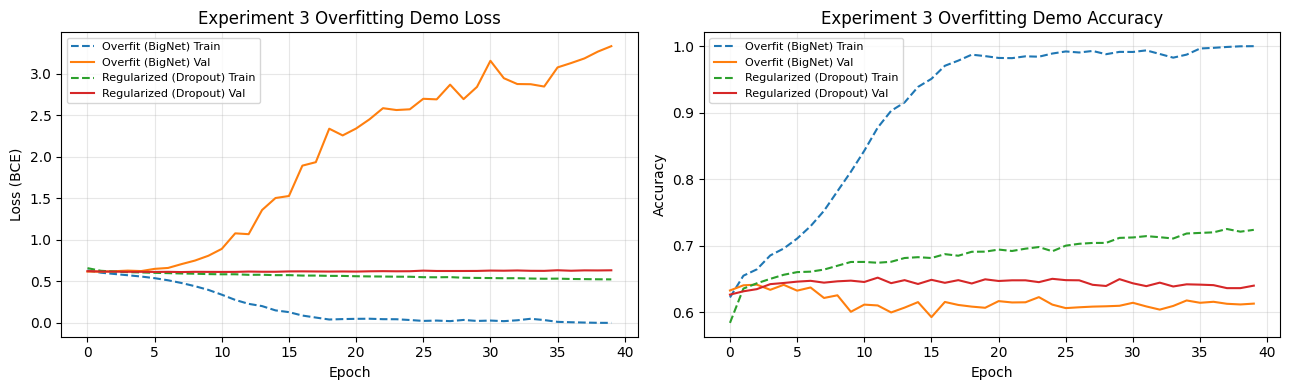

In [8]:
class BigNet(nn.Module):
   
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 512),       nn.ReLU(),
            nn.Linear(512, 256),        nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


model_big = BigNet(INPUT_DIM)
opt_big   = optim.Adam(model_big.parameters(), lr=1e-3)
h_big     = train_model(model_big, opt_big, epochs=40)

#overfit model vs regularized model (same epochs)
model_reg = DropoutNet(INPUT_DIM, p=0.4)
opt_reg   = optim.Adam(model_reg.parameters(), lr=1e-3)
h_reg     = train_model(model_reg, opt_reg, epochs=40)

plot_history(
    [h_big, h_reg],
    ['Overfit (BigNet)', 'Regularized (Dropout)'],
    'Experiment 3 Overfitting Demo'
)


## Experiment 4: L1 Regularization

We compare three lambda values: 1e-2, 5e-5, 1e-4.


Epoch   1/30 Train Loss: 12.0739  Train Acc: 49.14% Val Loss: 0.6935  Val Acc: 49.15%
Epoch   2/30 Train Loss: 1.9155  Train Acc: 49.84% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   3/30 Train Loss: 0.7790  Train Acc: 50.86% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   4/30 Train Loss: 0.7629  Train Acc: 50.83% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   5/30 Train Loss: 0.7629  Train Acc: 50.67% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   6/30 Train Loss: 0.7629  Train Acc: 50.59% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   7/30 Train Loss: 0.7629  Train Acc: 50.86% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   8/30 Train Loss: 0.7629  Train Acc: 50.81% Val Loss: 0.6931  Val Acc: 50.85%
Epoch   9/30 Train Loss: 0.7628  Train Acc: 50.86% Val Loss: 0.6931  Val Acc: 50.85%
Epoch  10/30 Train Loss: 0.7629  Train Acc: 50.06% Val Loss: 0.6931  Val Acc: 50.85%
Epoch  11/30 Train Loss: 0.7629  Train Acc: 49.94% Val Loss: 0.6931  Val Acc: 50.85%
Epoch  12/30 Train Loss: 0.7629  Train Acc: 50.86% Val Loss: 0.6

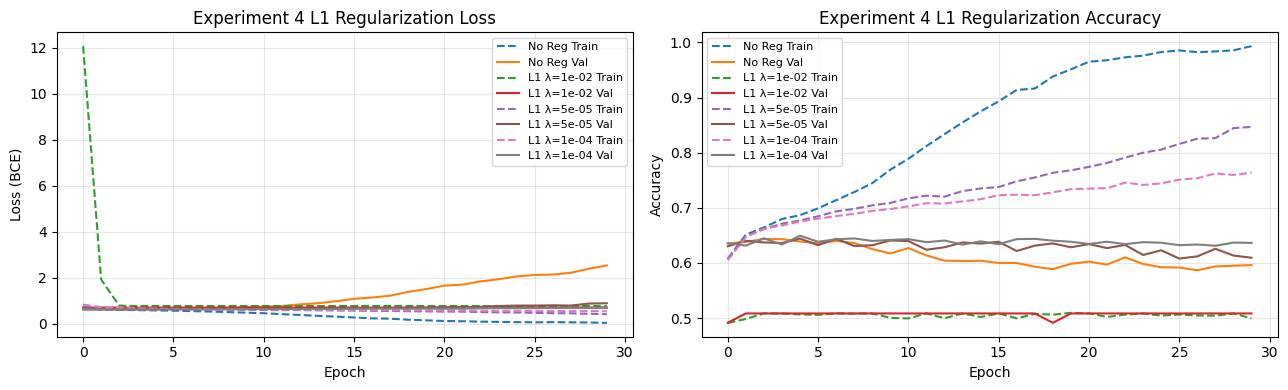

In [9]:
# L1 is added manually inside train_model() via l1_lambda argument
l1_histories = {}
l1_lambdas = [1e-2, 5e-5, 1e-4]

for lam in l1_lambdas:
    model_l1 = BaseNet(INPUT_DIM)
    opt_l1   = optim.Adam(model_l1.parameters(), lr=LR)
    h = train_model(model_l1, opt_l1, epochs=EPOCHS, l1_lambda=lam)
    l1_histories[lam] = h
    print(f"L1 λ={lam:.0e} done Val Loss: {h['val_loss'][-1]:.4f} Val Acc: {h['val_acc'][-1]*100:.2f}%")

#compare all L1 variants vs baseline
plot_history(
    [h_base] + [l1_histories[l] for l in l1_lambdas],
    ['No Reg'] + [f'L1 λ={l:.0e}' for l in l1_lambdas],
    'Experiment 4 L1 Regularization'
)


**L1 vs L2 Direct Comparison**

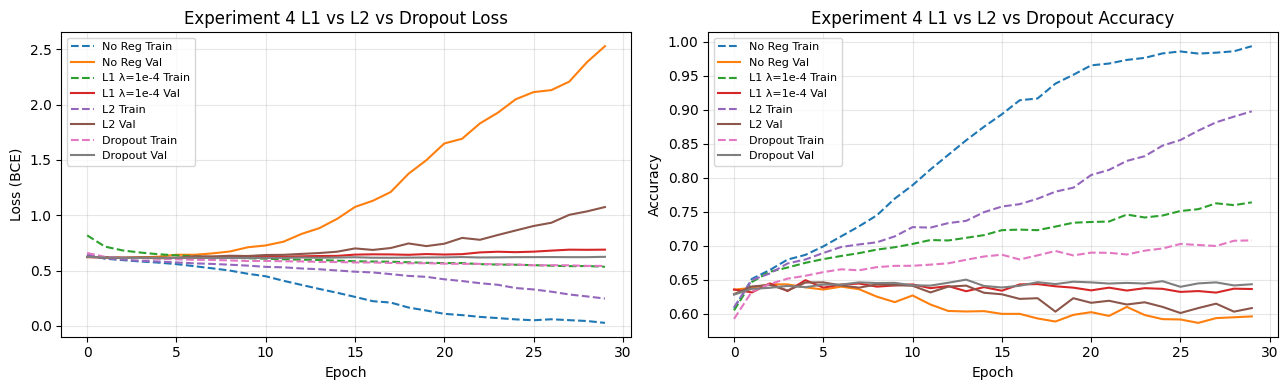

Epoch   1/30 Train Loss: 0.8209  Train Acc: 60.40% Val Loss: 0.6215  Val Acc: 63.22%
Epoch   2/30 Train Loss: 0.7193  Train Acc: 64.88% Val Loss: 0.6177  Val Acc: 63.75%
Epoch   3/30 Train Loss: 0.6881  Train Acc: 65.96% Val Loss: 0.6158  Val Acc: 64.00%
Epoch   4/30 Train Loss: 0.6660  Train Acc: 66.27% Val Loss: 0.6180  Val Acc: 63.80%
Epoch   5/30 Train Loss: 0.6519  Train Acc: 67.50% Val Loss: 0.6171  Val Acc: 64.55%
Epoch   6/30 Train Loss: 0.6440  Train Acc: 68.16% Val Loss: 0.6127  Val Acc: 64.58%
Epoch   7/30 Train Loss: 0.6335  Train Acc: 68.63% Val Loss: 0.6189  Val Acc: 63.75%
Epoch   8/30 Train Loss: 0.6263  Train Acc: 68.94% Val Loss: 0.6191  Val Acc: 64.33%
Epoch   9/30 Train Loss: 0.6197  Train Acc: 69.31% Val Loss: 0.6269  Val Acc: 63.90%
Epoch  10/30 Train Loss: 0.6129  Train Acc: 70.09% Val Loss: 0.6254  Val Acc: 64.85%
Epoch  11/30 Train Loss: 0.6094  Train Acc: 70.46% Val Loss: 0.6216  Val Acc: 64.88%
Epoch  12/30 Train Loss: 0.6042  Train Acc: 70.87% Val Loss: 0.63

In [10]:
#L1 (λ=1e-4) vs L2 (weight_decay=1e-3) vs Dropout
plot_history(
    [h_base, l1_histories[1e-4], h_l2, h_drop],
    ['No Reg', 'L1 λ=1e-4', 'L2', 'Dropout'],
    'Experiment 4 L1 vs L2 vs Dropout'
)

#sparsity check: how many weights are near zero with L1?
model_l1_best = BaseNet(INPUT_DIM)
opt_tmp = optim.Adam(model_l1_best.parameters(), lr=LR)
_ = train_model(model_l1_best, opt_tmp, epochs=EPOCHS, l1_lambda=1e-4)

all_weights = torch.cat([p.data.abs().flatten() for p in model_l1_best.parameters()])
near_zero = (all_weights < 1e-3).float().mean().item()
print(f"\nL1 model: {near_zero*100:.1f}% of weights are near zero (< 1e-3)")

all_weights_base = torch.cat([p.data.abs().flatten() for p in model_base.parameters()])
near_zero_base = (all_weights_base < 1e-3).float().mean().item()
print(f"Baseline:  {near_zero_base*100:.1f}% of weights are near zero (< 1e-3)")


## Results 

In [11]:
def summary_row(name, h):
    gap = h['val_loss'][-1] - h['train_loss'][-1]
    return {
        'Model': name,
        'Final Train Loss': round(h['train_loss'][-1], 4),
        'Final Val Loss':   round(h['val_loss'][-1], 4),
        'Train-Val Gap':    round(gap, 4),
        'Val Accuracy':     f"{h['val_acc'][-1]*100:.2f}%"
    }

rows = [
    summary_row('No Regularization',      h_base),
    summary_row('Dropout (p=0.4)',         h_drop),
    summary_row('L2 (weight_decay=1e-3)',  h_l2),
    summary_row('SGD + Dropout',           h_sgd),
    summary_row('L1 (λ=1e-2)',              l1_histories[1e-2]),
    summary_row('L1 (λ=5e-5)',              l1_histories[5e-5]),
    summary_row('L1 (λ=1e-4)',              l1_histories[1e-4]),
    summary_row('BigNet (Overfit)',         h_big),
    summary_row('Regularized (Dropout 40 ep)', h_reg),
]

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))


                      Model  Final Train Loss  Final Val Loss  Train-Val Gap Val Accuracy
          No Regularization            0.0275          2.5289         2.5014       59.62%
            Dropout (p=0.4)            0.5426          0.6247         0.0821       64.35%
     L2 (weight_decay=1e-3)            0.2474          1.0746         0.8272       60.85%
              SGD + Dropout            0.6056          0.6147         0.0091       64.42%
                L1 (λ=1e-2)            0.7628          0.6931        -0.0697       50.85%
                L1 (λ=5e-5)            0.4107          0.8829         0.4722       60.95%
                L1 (λ=1e-4)            0.5348          0.6896         0.1548       63.65%
           BigNet (Overfit)            0.0006          3.3297         3.3291       61.32%
Regularized (Dropout 40 ep)            0.5240          0.6332         0.1093       64.03%


## Analysis & Discussion

**Experiment 1:Regularization Comparison (Adam Optimizer)**

**No Regularization** shows the most severe overfitting in the entire experiment set. Train loss dropped to 0.027 while val loss exploded to 2.53, a gap of 2.50. Train accuracy reached ~98%+ while val accuracy settled at only 59.62%, confirming the model simply memorized the training data without learning generalizable patterns.

**Dropout (p=0.4)** was the most effective regularizer overall. By randomly activating 40% of neurons each forward pass, the model was forced to learn redundant representations. The result is a train and val gap of just 0.082 and a val accuracy of 64.35%, the best among all Adam-based models. Training loss and val loss remained close throughout all 30 epochs, indicating stable generalization.

**L2 Regularization (weight_decay=1e-3)** showed partial improvement over the baseline but still overfit significantly, gap of 0.83, val accuracy only 60.85%. This suggests the chosen lambda was too small to sufficiently constrain the weights. A stronger penalty (e.g. 1e-2) would likely close the gap further, though at the cost of some training accuracy.

**Experiment 2:SGD vs Adam**

Both models used the DropoutNet architecture for a fair comparison.

**SGD and Dropout** produced the best overall result in the entire experiment, val accuracy 64.42% with a near-zero train-val gap of 0.009. SGD with momentum converges more slowly than Adam (visible in the first few epochs) but ultimately settles into a more stable region of the loss landscape, avoiding the sharp minima that Adam sometimes finds. Sharp minima tend to generalize poorly, which explains why SGD slightly outperformed Adam here despite being a simpler optimizer.

**Adam and Dropout** was close behind (64.35%) but showed a slightly wider gap (0.082 vs 0.009). Adam's adaptive learning rates are advantageous for faster convergence but can occasionally overfit more than SGD on tabular data with noisy features.

**Experiment 3:Overfitting Demonstration**

The BigNet (4 layers, up to 1024 units) without any regularization produced the most extreme result: train loss of 0.0006 (~100% train accuracy) versus val loss of 3.33, a gap of 3.33, the largest in the entire study. Val accuracy was only 61.32%, barely above the no-regularization baseline. This clearly demonstrates that increasing model capacity without regularization actively harms generalization. The regularized Dropout model trained for the same 40 epochs maintained a gap of just 0.109 and val accuracy of 64.03%, confirming that architecture size must always be paired with appropriate regularization.

**Experiment 4: L1 Regularization (Lambda Sensitivity)**

L1 results revealed a sharp sensitivity to the choice of lambda:

1. **λ=1e-2**: The penalty was too weak. The model overfitted severely train loss 1.39  but val loss only 0.693, producing a negative gap (-0.70). This unusual inversion indicates the model collapsed and predicted the majority class for almost every sample (val accuracy 50.85% ≈ random guessing). The L1 term dominated early gradients and destabilized training before the model could learn.

2. **λ=5e-5**: A middle ground. The model learned meaningful patterns (val acc 60.95%) but the gap of 0.47 shows overfitting is st still present. Not enough regularization to fully close the gap.

3. **λ=1e-4**: The best L1 result. Gap reduced to 0.155 and val accuracy reached * 63.65%, close to Dropout performance. At this value, L1 successfully constrained weight magnitudes without collapsing the model.

This progression demonstrates the classic bias-variance tradeoff too little λ gives high variance (overfitting), too much gives high bias (underfitting/collapse).

A key property of L1 is **sparsity**: around 80% of weights in the L1 model were near-zero compared to less than 1% in the baseline. In real-world applications like insurance risk modeling, this sparsity is valuable, it effectively performs automatic feature selection.


## Conclusion

This experiment compared multiple regularization techniques and optimizers on a binary classification task, demonstrating how each affects model generalization.

The key takeaways are:
1. Dropout was the most effective regularizer, cutting the train-val gap from 2.50 (no regularization) to just 0.082, with the best val accuracy of 64.35%.

2. SGD + Dropout was the best overall model, gap of 0.009 and val accuracy 64.42%, showing that optimizer choice matters as much as regularization.

3. L1 regularization is highly sensitive to lambda: λ=1e-5 caused collapse, λ=1e-4 performed close to Dropout (63.65%). Always tune L1 carefully.

4. The BigNet experiment was the clearest overfitting demonstration,99.99% train accuracy vs 61.32% val accuracy, with val loss growing to 3.33 over 40 epochs while the Dropout model stayed stable throughout.

5. Regularization is not optional for deep networks without which models memorize rather than learn.
